## Introduction

In this code, an overview of the available Sentinel-2 and Sentinel-3 images are given for a given Area Of Interest (AOI). As an example, the area of Brussels, Belgium is chosen.

This code is heavily based on this EOPF code [here](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html).

In [34]:
!pip install dask[distributed] pystac_client xarray-eopf fsspec==2025.3.0  --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.7 MB/s eta 0:00:00


In [35]:
import geopandas as gpd
import xarray as xr
from dask.distributed import Client as DaskClient
from pystac import MediaType
from pystac_client import Client
from datetime import datetime

Reading in a Geojson file for the Brussels area, Belgium:

In [36]:
brussels_file_path = 'https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson'

In [37]:
!wget -O brussels_dissolved.geojson \
$brussels_file_path

--2026-03-12 07:10:06--  https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1146031685/4f733533-4c44-4190-a222-81ffea022025?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-12T07%3A46%3A49Z&rscd=attachment%3B+filename%3Dbrussels_dissolved.geojson&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-12T06%3A46%3A08Z&ske=2026-03-12T07%3A46%3A49Z&sks=b&skv=2018-11-09&sig=C%2FlBt7hn%2FUVOCIJNpVKGItEFTRL%2FANrzz91cHs18rVc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzI5OTcwNiwibmJmIjoxNzczMjk5NDA2LCJwYXRoIjoicmVsZWFzZWFzc

<Axes: >

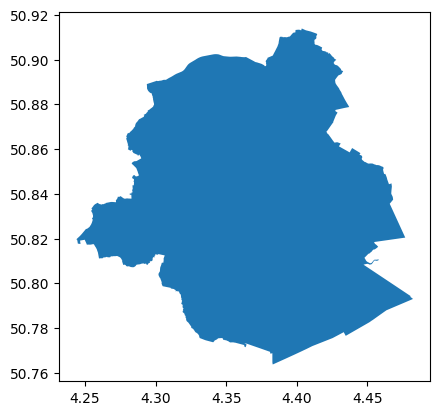

In [38]:
gdf = gpd.read_file('/content/brussels_dissolved.geojson')
gdf.plot()

Compute a bounding box computing the latitude and longitude for the Brussels area:

In [39]:
## Code obtained from:
## https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html
eopf_catalog = Client.open(url="https://stac.core.eopf.eodc.eu/")
## eopf_catalog

Print the collections in the catalogue:

In [40]:
for collection in eopf_catalog.get_all_collections():
        print(collection.id)

sentinel-2-l2a
sentinel-1-l1-grd
sentinel-3-slstr-l2-lst
sentinel-3-slstr-l2-frp
sentinel-3-olci-l2-lfr
sentinel-3-olci-l2-lrr
sentinel-3-olci-l1-efr
sentinel-1-l2-ocn
sentinel-3-slstr-l1-rbt
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-olci-l1-err


In [41]:
# Set parameters:
period = "2025-06-01/2025-08-31"

# https://pystac-client.readthedocs.io/en/latest/tutorials/item-search-intersects.html
aoi = gdf.geometry.iloc[0].__geo_interface__

## Sentinel-2 search

In [42]:
items_s2 = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    datetime=period
   ).item_collection()

/usr/local/lib/python3.12/dist-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20250630T104041_N0511_R008_T31UFS_20250630T161206' is deprecated.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206' is deprecated.
  warnings.warn(


In [20]:
print(f'There are {len(items_s2)} items in the S2-collection')

There are 9 items in the S2-collection


In [21]:
for item in items_s2:
    print(item)

<Item id=S2C_MSIL2A_20250730T104041_N0511_R008_T31UFS_20250730T160714>
<Item id=S2C_MSIL2A_20250730T104041_N0511_R008_T31UES_20250730T160714>
<Item id=S2A_MSIL2A_20250725T105051_N0511_R051_T31UFS_20250725T122714>
<Item id=S2B_MSIL2A_20250725T103629_N0511_R008_T31UFS_20250725T130225>
<Item id=S2B_MSIL2A_20250725T103629_N0511_R008_T31UES_20250725T130225>
<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UFS_20250630T161206>
<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206>
<Item id=S2B_MSIL2A_20250608T104619_N0511_R051_T31UFS_20250608T115829>
<Item id=S2B_MSIL2A_20250608T104619_N0511_R051_T31UES_20250608T115829>


In [43]:
items_s2[1]

<Item id=S2C_MSIL2A_20250730T104041_N0511_R008_T31UES_20250730T160714>

Filter now with less cloud cover, enough data coverage and the 31UES tile:

In [44]:
filters = {
    "eo:cloud_cover":{"lt":50},
}

In [45]:
items_s2_filtered = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    query=filters,
    datetime=period).item_collection()

In [46]:
print(f'There are {len(items_s2_filtered)} items in the S2-collection')

There are 2 items in the S2-collection


In [47]:
for item in items_s2_filtered:
  print(item)

<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UFS_20250630T161206>
<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206>


In [48]:
## If you change the index, you can have a quick look at what is in these files
items_s2_filtered[1]

<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206>

In [49]:
## Show the preview:
items_s2_filtered[1].assets.keys()

dict_keys(['SR_10m', 'SR_20m', 'SR_60m', 'AOT_10m', 'B01_20m', 'B02_10m', 'B03_10m', 'B04_10m', 'B05_20m', 'B06_20m', 'B07_20m', 'B08_10m', 'B09_60m', 'B11_20m', 'B12_20m', 'B8A_20m', 'SCL_20m', 'TCI_10m', 'WVP_10m', 'product', 'product_metadata'])

We follow the [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html) to have a quick look at the image.

Select all the .zarr files from this item:

In [50]:
item = items_s2_filtered[1]
item_assets = item.get_assets(media_type=MediaType.ZARR)
item_assets

{'SR_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v256/S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206.zarr/measurements/reflectance/r10m>,
 'SR_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v256/S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206.zarr/measurements/reflectance/r20m>,
 'SR_60m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v256/S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206.zarr/measurements/reflectance/r60m>,
 'AOT_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v256/S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206.zarr/quality/atmosphere/r10m/aot>,
 'B01_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v25

In [51]:
cloud_storage = item_assets['product'].href
cloud_storage

'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil2a/30/products/cpm_v256/S2C_MSIL2A_20250630T104041_N0511_R008_T31UES_20250630T161206.zarr'

In [52]:
client = DaskClient()  # Set up local dask cluster
client

dt = xr.open_datatree(
    cloud_storage,
    engine="zarr",
    ## engine="eopf-zarr",
    chunks="auto"
)

# for dt_group in sorted(dt.groups):
#     print("DataTree group {group_name}".format(group_name=dt_group)) # getting the available groups

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40431 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:41605
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:40431/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34785'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:32971'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33723 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33723
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:55924
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37609 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37609
IN

ValueError: unrecognized engine 'zarr' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

## Quick visualisation

## Computation of the NDVI

## References

https://carpentries-incubator.github.io/geospatial-python/05-access-data.html

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html

https://pystac-client.readthedocs.io/en/latest/tutorials/item-search-intersects.html

